# Model 08: Random Forest Classifier

### Objective
Uses an ensemble of 100 Decision Trees to predict the probability of a lecture falling into the High, Medium, or Low band. Highly robust against overfitting.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('evidence', exist_ok=True)

### 1. Load Datasets & Encode Targets

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
y_train_raw = pd.read_csv('../../../../../data/processed/y_train_class.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val_raw = pd.read_csv('../../../../../data/processed/y_val_class.csv').squeeze()

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_val = le.transform(y_val_raw)

print("Classes:", le.classes_)
print("Datasets loaded successfully.")

Classes: ['High' 'Low' 'Medium']
Datasets loaded successfully.


### 2. Model Training

In [3]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("✅ Random Forest Classifier Trained Successfully.")

✅ Random Forest Classifier Trained Successfully.

### 3. Classification Evaluation

In [4]:
def evaluate_classification(model, X, y_true, model_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    try:
        y_prob = model.predict_proba(X)
        roc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    except AttributeError:
        roc = np.nan
        
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if not np.isnan(roc):
        print(f"ROC-AUC:  {roc:.4f}\n")
    else:
        print("ROC-AUC:  N/A\n")
        
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_pred, acc, f1, roc

print("========== TRAINING SET ==========")
_, train_acc, train_f1, train_roc = evaluate_classification(rf_model, X_train, y_train, "08_random_forest_classifier (TRAIN)")

print("========== VALIDATION SET ==========")
val_preds, val_acc, val_f1, val_roc = evaluate_classification(rf_model, X_val, y_val, "08_random_forest_classifier (VAL)")

========== TRAINING SET ==========
--- 08_random_forest_classifier (TRAIN) ---
Accuracy: 0.9914
F1 Score: 0.9912
ROC-AUC:  0.9997

              precision    recall  f1-score   support

        High       1.00      0.97      0.99       105
         Low       0.98      1.00      0.99       124
      Medium       1.00      1.00      1.00       121

    accuracy                           0.99       350
   macro avg       0.99      0.99      0.99       350
weighted avg       0.99      0.99      0.99       350

========== VALIDATION SET ==========
--- 08_random_forest_classifier (VAL) ---
Accuracy: 0.3467
F1 Score: 0.3468
ROC-AUC:  0.5752

              precision    recall  f1-score   support

        High       0.21      0.44      0.28        16
         Low       0.44      0.33      0.38        24
      Medium       0.48      0.31      0.38        35

    accuracy                           0.35        75
   macro avg       0.38      0.36      0.35        75
weighted avg       0.41      0.

### 4. Confusion Matrix

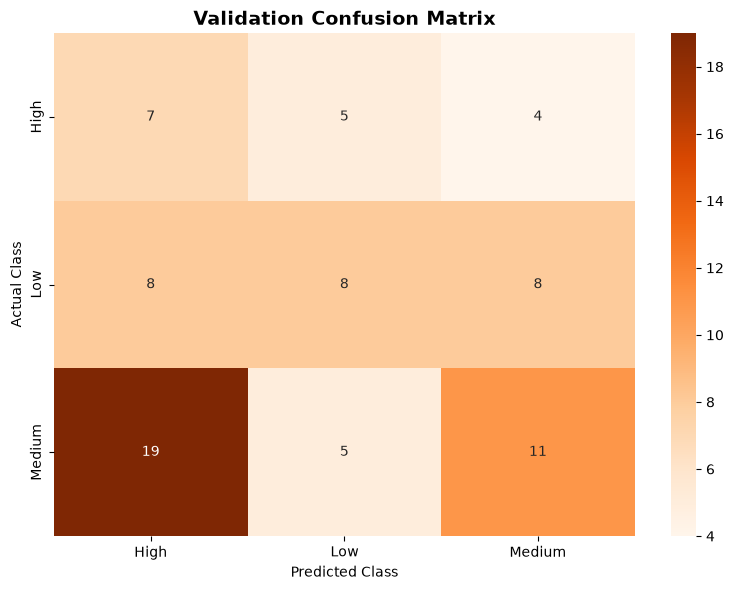

In [5]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('evidence/01_rf_confusion_matrix.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [6]:
import datetime
import os

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['08_random_forest_classifier'],
    'Model_Type': ['Classification'],
    'Val_MAE': [np.nan],
    'Val_RMSE': [np.nan],
    'Val_MAPE': [np.nan],
    'Val_R2': [np.nan],
    'Val_Accuracy': [val_acc],
    'Val_F1': [val_f1],
    'Val_ROCAUC': [val_roc]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
